In [6]:
import logging
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from linear_operator.operators import to_linear_operator
from sklearn.metrics import mean_squared_error

from student.constants import EPSILON, JITTER
from student.kernels import matern52_kernel, rbf_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma, 
    kl_gaussian_gamma_covariance_param,
    get_optimal_gaussian_gamma,
)


class TPR(nn.Module):

    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=0.1, scale=0.5)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Register non-trainable buffers for the Normal-Gamma distribution q(f,r)
        self.register_buffer('m_f', torch.zeros(self.N, 1, dtype=dtype))
        self.register_buffer('S_f', torch.eye(self.N, dtype=dtype))
        self.register_buffer('alpha_r', dof_func / 2.0)
        self.register_buffer('beta_r', dof_func / 2.0)

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = init_val
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX, local_params):
        alpha_lambda, beta_lambda = local_params
        params = self._get_hyperparams()
        
        # Term 1: Expected Log Likelihood
        E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda.clamp(min=EPSILON))
        
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
        var_f = E_r_inv * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
        
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * params["noisescale"]) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / params["noisescale"]
        )
        
        # --- 2. KL Divergence KL(q(lambda) || p(lambda)) ---
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # --- 3. KL Divergence KL(q(f,r) || p(f,r)) ---
        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), 
            S_q=self.S_f, 
            alpha_q=self.alpha_r, 
            beta_q=self.beta_r,
            mu_p=prior_mean_f, 
            K_p=K_XX.to_dense(), 
            alpha_p=p_alpha_r, 
            beta_p=p_beta_r
        )
        
        return exp_log_lik - kl_lambda - kl_f_r

    def _e_step(self, K_XX_op, params):
        """
        Performs the full-batch CAVI update loop.
        """
        with torch.no_grad():
            # K_XX = K_XX_op.to_dense() # Work with dense tensors inside the loop
            K_XX = K_XX_op.to_dense()
            identity = torch.eye(self.N, device=self.device, dtype=K_XX.dtype)
            sigma2 = params['noisescale']

            # Update q(lambda) parameters
            E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
            var_f = E_r_inv * torch.diag(self.S_f)
            E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
            
            alpha_lambda = params['dof_lik'] / 2.0 + 0.5
            beta_lambda = params['dof_lik'] / 2.0 + 0.5 * E_sq_err / sigma2
            E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)

            K_XX_inv = K_XX_op.solve(identity)
            K_XX_inv = to_linear_operator(K_XX_inv)
            E_r = self.alpha_r / self.beta_r.clamp(min=EPSILON)
            
            # Update q(f) parameters
            target_S_f_inv = E_r * K_XX_inv + torch.diag(E_lambda) / sigma2
            target_S_f = target_S_f_inv.solve(identity)
            target_m_f_term = (E_lambda * self.y_full.squeeze()) / sigma2
            target_m_f = target_S_f @ target_m_f_term.unsqueeze(1)
            
            # Update q(r) parameters based on the new q(f)
            target_alpha_r = params['dof_func'] / 2.0 + self.N / 2.0
            trace_term = torch.trace(K_XX_inv @ target_S_f)
            quad_term = target_m_f.T @ K_XX_inv @ target_m_f
            target_beta_r = params['dof_func'] / 2.0 + (trace_term + quad_term) / 2.0

            # Solve another variational problem argmin KL(q(f,r)||q(f)q(r))
            _, S_f_proj, _, _ = get_optimal_gaussian_gamma(
                target_m_f,
                target_S_f,
                target_alpha_r,
                target_beta_r
            )

            self.m_f.data      = target_m_f
            self.S_f.data      = S_f_proj
            self.alpha_r.data  = target_alpha_r
            self.beta_r.data   = target_beta_r

            return alpha_lambda, beta_lambda

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        
    
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [],
            'lengthscale': [], 'outputscale': [], 'dof_func': [], 'dof_lik': [], 'noisescale': [],
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):

            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX = K_XX_base.add_jitter(JITTER)
            local_params = self._e_step(K_XX, params)
            elbo = self._calculate_elbo(K_XX, local_params)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)

            fit_end_time = time.time()

            # --- Store history ---
            params_final = self._get_hyperparams()
            history['elbo'].append(elbo.item())
            history['log_prior'].append(log_prior.item())
            history['loss'].append(loss.item())
            history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
            history['outputscale'].append(params_final['outputscale'].item())
            history['noisescale'].append(params_final['noisescale'].item())
            history['dof_func'].append(params_final['dof_func'].item())
            history['dof_lik'].append(params_final['dof_lik'].item())
            history['fit_times'].append(fit_end_time - fit_start_time)

                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:3d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise2: {params_final['noisescale']:3f} | dof_func: {params_final['dof_func']:.2f} | dof_lik: {params_final['dof_lik']:.2f}")

            # --- Evaluation Step ---
            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(
                    f"Epoch {epoch+1:3d}/{epochs} | Test Metrics: "
                    f"RMSE: {metrics['rmse']:.3f}"
                )

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            # Assuming k_star_star is constant, equal to outputscale
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean)
            K_XX_inv_mf = K_XX.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_star_X @ K_XX.solve(torch.eye(self.N, device=self.device))
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': scale_sq_star.clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        """Evaluates the model on test data and returns a dictionary of metrics."""
        self.eval()
        with torch.no_grad():
            f_pred_tensor = self.predict(X_test)
            f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
            y_true_numpy = y_test.cpu().numpy()

            # metrics = {
            #     'rmse': np.sqrt(np.mean((y_true_numpy - f_pred_numpy)**2))
            # }
            metrics = {
                'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))
            }
        self.train()
        return metrics

In [12]:
# TPRクラスの修正版 (linear_operatorを最大限活用)
# gpytorch/linear_operator ライブラリが必要です
# pip install gpytorch
from linear_operator.operators import AddedDiagLinearOperator

class TPR(nn.Module):

    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=0.1, scale=0.5)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Register non-trainable buffers for the Normal-Gamma distribution q(f,r)
        self.register_buffer('m_f', torch.zeros(self.N, 1, dtype=dtype))
        self.register_buffer('S_f', torch.eye(self.N, dtype=dtype))
        self.register_buffer('alpha_r', dof_func / 2.0)
        self.register_buffer('beta_r', dof_func / 2.0)

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX, local_params):
        alpha_lambda, beta_lambda = local_params
        params = self._get_hyperparams()
        
        E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda.clamp(min=EPSILON))
        
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
        var_f = E_r_inv * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
        
        noise_var = params["noisescale"]
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_var) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / noise_var
        )
        
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), S_q=self.S_f, alpha_q=self.alpha_r, beta_q=self.beta_r,
            mu_p=prior_mean_f, K_p=K_XX.to_dense(), alpha_p=p_alpha_r, beta_p=p_beta_r
        )
        
        return exp_log_lik - kl_lambda - kl_f_r

    def _e_step(self, K_XX_op, params):
        with torch.no_grad():
            identity = torch.eye(self.N, device=self.device, dtype=self.X_full.dtype)
            sigma2 = params['noisescale']

            E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
            var_f = E_r_inv * torch.diag(self.S_f)
            E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
            
            alpha_lambda = (params['dof_lik'] / 2.0 + 0.5).expand(self.N)
            beta_lambda = params['dof_lik'] / 2.0 + 0.5 * E_sq_err / sigma2
            E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
            
            E_r = self.alpha_r / self.beta_r.clamp(min=EPSILON)
            
            # --- Update q(f) parameters using linear operators ---
            ### <<< 修正: 逆行列計算をAddedDiagLinearOperatorとsolveに置き換え
            # target_S_f_inv = E_r * K_XX_inv + diag(E_lambda / sigma2)
            K_XX_inv = K_XX_op.solve(identity)
            K_XX_inv_op = to_linear_operator(K_XX_inv)
            scaled_K_XX_inv_op = K_XX_inv_op.mul(E_r)
            
            target_S_f_inv_op = scaled_K_XX_inv_op + torch.diag(E_lambda / sigma2)
            
            # S_f = (S_f_inv)^-1
            target_S_f = target_S_f_inv_op.solve(identity)
            
            # m_f = S_f @ (E_lambda * y / sigma2)
            target_m_f_term = (E_lambda * self.y_full.squeeze()) / sigma2
            target_m_f = target_S_f @ target_m_f_term.unsqueeze(1)
            
            # --- Update q(r) parameters based on the new q(f) ---
            target_alpha_r = params['dof_func'] / 2.0 + self.N / 2.0
            
            ### <<< 修正: K_XX_inv @ target_S_f のトレース計算
            # K_XX.solve() を使って効率的に計算
            trace_term = torch.trace(K_XX_op.solve(target_S_f))
            
            ### <<< 修正: m.T @ K_inv @ m の計算
            K_inv_m = K_XX_op.solve(target_m_f)
            quad_term = (target_m_f.T @ K_inv_m).squeeze()
            
            target_beta_r = params['dof_func'] / 2.0 + (trace_term + quad_term) / 2.0

            _, S_f_proj, _, _ = get_optimal_gaussian_gamma(
                target_m_f, target_S_f, target_alpha_r, target_beta_r
            )

            self.m_f.data      = target_m_f
            self.S_f.data      = S_f_proj
            self.alpha_r.data  = target_alpha_r
            self.beta_r.data   = target_beta_r

            return alpha_lambda, beta_lambda

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            local_params = self._e_step(K_XX_op, params)
            elbo = self._calculate_elbo(K_XX_op, local_params)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale: scale^2 = (beta/alpha) * (k_** - K_*X @ K_XX^-1 @ K_X* + Tr( (K_*X @ K_XX^-1) @ S_f @ (K_*X @ K_XX^-1)^T ))
            # Let A = K_*X @ K_XX^-1
            # A = K_star_X @ K_XX_op.solve(torch.eye(...)) だが、これは非効率
            # (K_XX_op^T).solve(K_star_X^T) の方が効率的
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics

In [14]:

# --- メインの実行ブロック ---
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    
    # ロギング設定
    logging.basicConfig(level=logging.INFO, format='%(message)s')
    
    # 1. データの生成
    # ------------------------------------
    def true_function(x):
        return np.sin(x * 2.5) * np.exp(-x * 0.8)

    # トレーニングデータを疎に生成し、異質分散性のノイズを追加
    N_train = 40
    X_train_np = np.concatenate([
        np.linspace(-1, 0.5, int(N_train*0.4)),
        np.linspace(1.5, 3, int(N_train*0.6))
    ])
    # x=1.0 付近でノイズが大きくなるように設定
    noise_level = 0.05 + 0.25 * np.exp(-(X_train_np - 1.0)**2 / 0.1)
    y_train_np = true_function(X_train_np) + np.random.normal(0, noise_level)
    
    # テストデータを密に生成してプロット用にする
    N_test = 200
    X_test_np = np.linspace(-2, 4, N_test)
    y_test_np = true_function(X_test_np)

    # PyTorchテンソルに変換
    X_train = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.float32)

    # 2. モデルの初期化
    # ------------------------------------
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logging.info(f"Using device: {device}")

    # ハイパーパラメータの設定
    # 自由度は固定し、他のパラメータはMAP推定（事前分布を考慮した最尤推定）で学習
    hyper_settings = {
        "lengthscale": {"optim": "MLE"},
        "outputscale": {"optim": "FIX", "init": 1.0},
        "dof_func":    {"optim": "MLE"},
        "dof_lik":     {"optim": "MLE"},
        "noisescale":  {"optim": "MLE"}
    }

    model = TPR(X_train, y_train, hyper_settings=hyper_settings, kernel="rbf", device=device)

    # 3. モデルの学習
    # ------------------------------------
    # テストデータを渡すことで、学習中に評価メトリクスを計算できる
    history = model.fit(epochs=250, hyper_lr=0.01, X_test=X_test, y_test=y_test, eval_interval=25)

    # 4. 予測
    # ------------------------------------
    predictions = model.predict(X_test)
    pred_loc = predictions['loc'].cpu().numpy()
    pred_scale_sq = predictions['scale_sq'].cpu().numpy()
    pred_dof = predictions['dof'].cpu().numpy()

    # Student-t分布から95%信頼区間を計算
    pred_scale = np.sqrt(pred_scale_sq)
    # ppfはパーセント点関数（累積分布関数の逆関数）
    alpha_ci = 0.05
    t_value = student_t.ppf(1 - alpha_ci / 2, df=pred_dof)
    lower_bound = pred_loc - t_value * pred_scale
    upper_bound = pred_loc + t_value * pred_scale

    # 5. 結果の可視化
    # ------------------------------------
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # --- 回帰結果のプロット ---
    ax1.plot(X_test_np, y_test_np, 'k-', label='True Function', linewidth=2)
    ax1.scatter(X_train_np, y_train_np, c='r', marker='x', label='Training Data')
    ax1.plot(X_test_np, pred_loc, 'b-', label='Predictive Mean', linewidth=2)
    ax1.fill_between(X_test_np, lower_bound, upper_bound, color='b', alpha=0.2, label='95% Confidence Interval')
    ax1.set_title('Student-t Process Regression', fontsize=16)
    ax1.set_xlabel('X', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.set_ylim(-2, 2)
    ax1.set_xlim(-2, 4)

    # --- ELBOの履歴のプロット ---
    ax2.plot(history['elbo'], label='ELBO')
    ax2.set_title('ELBO convergence', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('ELBO', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # 最終的なハイパーパラメータの表示
    final_params = model._get_hyperparams()
    logging.info("\n--- Final Hyperparameters ---")
    logging.info(f"Lengthscale: {final_params['lengthscale'].detach().cpu().numpy()}")
    logging.info(f"Outputscale (Signal Variance): {final_params['outputscale'].item():.4f}")
    logging.info(f"Noisescale: {final_params['noisescale'].item():.4f}")
    logging.info(f"Function DoF: {final_params['dof_func'].item():.2f}")
    logging.info(f"Likelihood DoF: {final_params['dof_lik'].item():.2f}")

Using device: cuda
Sampled initial lengthscale (Optim mode: MLE): [0.07376173]
Using provided initial outputscale (Optim mode: FIX): 1.0
Sampled initial dof_func (Optim mode: MLE): 2.0
Sampled initial dof_lik (Optim mode: MLE): 2.0
Sampled initial noisescale (Optim mode: MLE): 0.915053129196167
Starting SVI optimization for 250 epochs...
Epoch   25/250 | Fit Time: 0.006s | ELBO:   -54.28 | l: [0.077] | var: 1.000 | noise_var: 0.724 | dof_f: 1.82 | dof_l: 1.90
Epoch   25/250 | Test RMSE: 1.1967
Epoch   50/250 | Fit Time: 0.006s | ELBO:   -50.42 | l: [0.099] | var: 1.000 | noise_var: 0.569 | dof_f: 1.43 | dof_l: 1.91
Epoch   50/250 | Test RMSE: 1.1739
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., a

NameError: name 'student_t' is not defined

Using device: cuda
Sampled initial lengthscale (Optim mode: MAP): [0.3283377]
Using provided initial outputscale (Optim mode: FIX): 1.0
Sampled initial dof_func (Optim mode: MLE): 8.788212776184082
Sampled initial dof_lik (Optim mode: MLE): 8.809109687805176
Sampled initial noisescale (Optim mode: MAP): 1.3018953800201416
Starting SVI optimization for 250 epochs...
Epoch   25/250 | Fit Time: 0.005s | ELBO:   -41.75 | l: [0.332] | var: 1.000 | noise_var: 1.015 | dof_f: 11.00 | dof_l: 11.22
Epoch   25/250 | Test RMSE: 1.1615
Epoch   50/250 | Fit Time: 0.005s | ELBO:   -36.84 | l: [0.333] | var: 1.000 | noise_var: 0.795 | dof_f: 13.57 | dof_l: 14.04
Epoch   50/250 | Test RMSE: 1.1613
Epoch   75/250 | Fit Time: 0.005s | ELBO:   -32.17 | l: [0.333] | var: 1.000 | noise_var: 0.629 | dof_f: 16.69 | dof_l: 17.20
Epoch   75/250 | Test RMSE: 1.1613
Epoch  100/250 | Fit Time: 0.005s | ELBO:   -27.72 | l: [0.333] | var: 1.000 | noise_var: 0.501 | dof_f: 20.34 | dof_l: 20.66
Epoch  100/250 | Test R

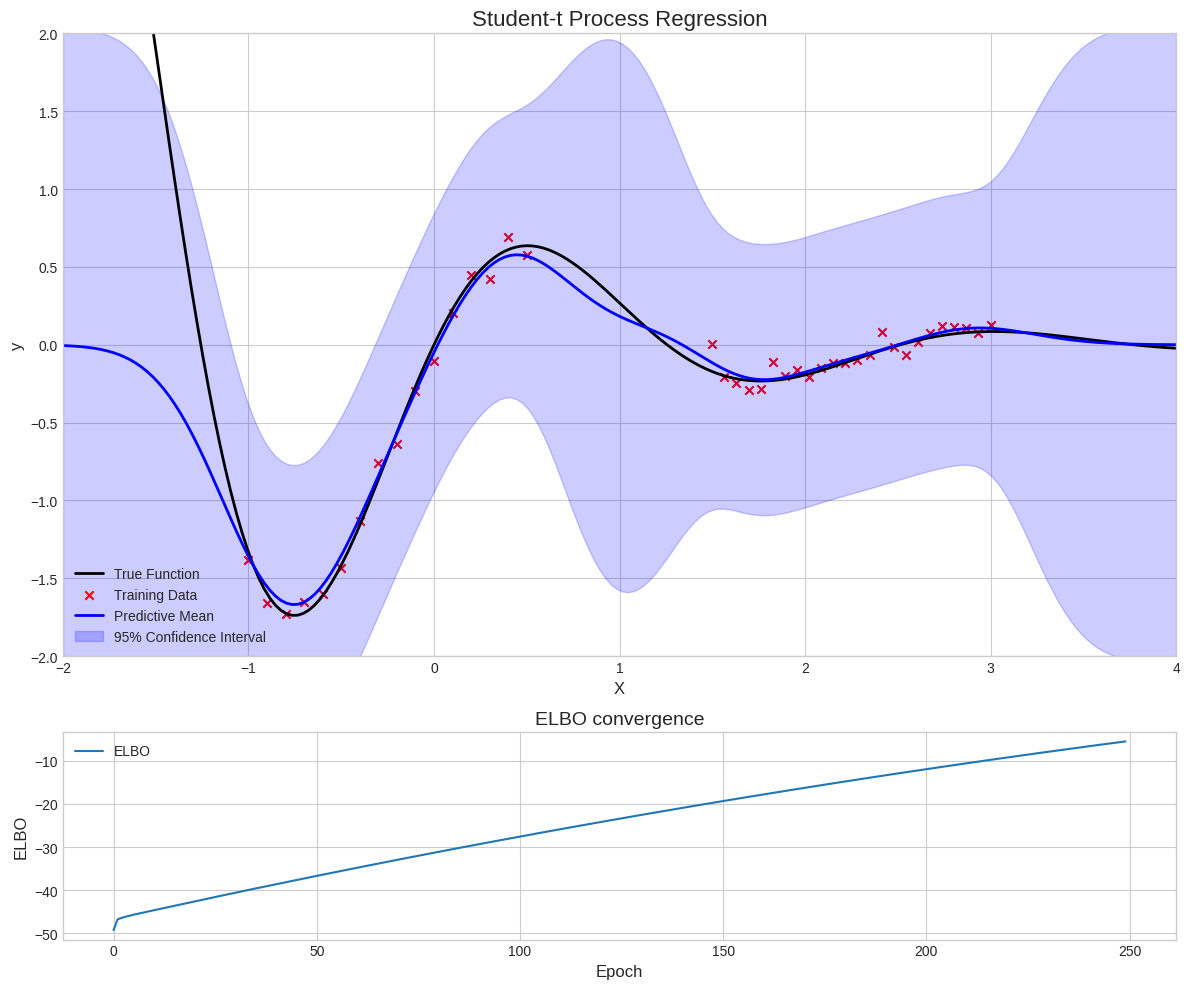


--- Final Hyperparameters ---
Lengthscale: [0.3333333]
Outputscale (Signal Variance): 1.0000
Noisescale (Noise Variance): 0.1589
Function DoF: 49.76
Likelihood DoF: 47.69


In [ ]:

class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=0.1, scale=0.5)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Register non-trainable buffers for the Normal-Gamma distribution q(f,r)
        self.register_buffer('m_f', torch.zeros(self.N, 1, dtype=dtype))
        self.register_buffer('S_f', torch.eye(self.N, dtype=dtype))
        self.register_buffer('alpha_r', dof_func / 2.0)
        self.register_buffer('beta_r', dof_func / 2.0)

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX, local_params):
        alpha_lambda, beta_lambda = local_params
        params = self._get_hyperparams()
        
        # 1. Expected Log-Likelihood
        E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda.clamp(min=EPSILON))
        
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
        var_f = E_r_inv * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
        
        noise_var = params["noisescale"]
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_var) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / noise_var
        )
        
        # 2. KL Divergence (Gamma)
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # 2. KL Divergence (Gaussian-Gamma)
        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), S_q=self.S_f, alpha_q=self.alpha_r, beta_q=self.beta_r,
            mu_p=prior_mean_f, K_p=K_XX.to_dense(), alpha_p=p_alpha_r, beta_p=p_beta_r
        )
        
        return exp_log_lik - kl_lambda - kl_f_r


    def _e_step(self, K_XX_op, params):
        with torch.no_grad():
            identity = torch.eye(self.N, device=self.device, dtype=self.X_full.dtype)
            sigma2 = params['noisescale']

            # Update q(λ) parameters
            E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
            var_f = E_r_inv * torch.diag(self.S_f)
            E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
            alpha_lambda = (params['dof_lik'] / 2.0 + 0.5).expand(self.N)
            beta_lambda = params['dof_lik'] / 2.0 + 0.5 * E_sq_err / sigma2
            
            # Update q(f), q(r) parameters independently
            E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
            E_r = self.alpha_r / self.beta_r.clamp(min=EPSILON)
            K_XX_inv = K_XX_op.solve(identity)
            scaled_K_XX_inv = K_XX_inv * E_r

            target_S_f_inv = scaled_K_XX_inv + torch.diag(E_lambda / sigma2)
            target_S_f_inv_op = to_linear_operator(target_S_f_inv)
            target_S_f = target_S_f_inv_op.solve(identity)
            target_m_f_term = (E_lambda * self.y_full.squeeze()) / sigma2
            target_m_f = target_S_f @ target_m_f_term.unsqueeze(1)
            
            target_alpha_r = params['dof_func'] / 2.0 + self.N / 2.0
            trace_term = torch.trace(K_XX_inv @ target_S_f)
            K_inv_m = K_XX_inv @ target_m_f
            quad_term = (target_m_f.T @ K_inv_m).squeeze()
            target_beta_r = params['dof_func'] / 2.0 + (trace_term + quad_term) / 2.0

            # Update q(f, r) via projection
            _, S_f_proj, _, _ = get_optimal_gaussian_gamma(
                target_m_f, target_S_f, target_alpha_r, target_beta_r
            )

            self.m_f.data      = target_m_f
            self.S_f.data      = S_f_proj
            self.alpha_r.data  = target_alpha_r
            self.beta_r.data   = target_beta_r

            return alpha_lambda, beta_lambda

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            local_params = self._e_step(K_XX_op, params)
            elbo = self._calculate_elbo(K_XX_op, local_params)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics
    


# --- メインの実行ブロック ---
if __name__ == '__main__':
    # ロギング設定
    logging.basicConfig(level=logging.INFO, format='%(message)s')
    
    # 1. データの生成
    # ------------------------------------
    def true_function(x):
        return np.sin(x * 2.5) * np.exp(-x * 0.8)

    N_train = 40
    X_train_np = np.concatenate([
        np.linspace(-1, 0.5, int(N_train*0.4)),
        np.linspace(1.5, 3, int(N_train*0.6))
    ])
    noise_level = 0.05 + 0.25 * np.exp(-(X_train_np - 1.0)**2 / 0.1)
    y_train_np = true_function(X_train_np) + np.random.normal(0, noise_level)
    
    N_test = 200
    X_test_np = np.linspace(-2, 4, N_test)
    y_test_np = true_function(X_test_np)

    X_train = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.float32)

    # 2. モデルの初期化
    # ------------------------------------
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logging.info(f"Using device: {device}")

    hyper_settings = {
        "lengthscale": {"optim": "MAP"},
        "noisescale":  {"optim": "MAP"},
        "outputscale": {"optim": "FIX", "init": 1.0},
        "dof_func":    {"optim": "MLE"},
        "dof_lik":     {"optim": "MLE"},
    }

    model = TPR(X_train, y_train, hyper_settings=hyper_settings, kernel="rbf", device=device)

    # 3. モデルの学習
    # ------------------------------------
    history = model.fit(epochs=250, hyper_lr=0.01, X_test=X_test, y_test=y_test, eval_interval=25)

    # 4. 予測
    # ------------------------------------
    predictions = model.predict(X_test)
    pred_loc = predictions['loc'].cpu().numpy()
    pred_scale_sq = predictions['scale_sq'].cpu().numpy()
    pred_dof = predictions['dof'].cpu().numpy()

    pred_scale = np.sqrt(pred_scale_sq)
    alpha_ci = 0.05
    # ### <<< 修正: student_t.ppf を使用
    t_value = student_t.ppf(1 - alpha_ci / 2, df=pred_dof)
    lower_bound = pred_loc - t_value * pred_scale
    upper_bound = pred_loc + t_value * pred_scale

    # 5. 結果の可視化
    # ------------------------------------
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(X_test_np, y_test_np, 'k-', label='True Function', linewidth=2)
    ax1.scatter(X_train_np, y_train_np, c='r', marker='x', label='Training Data')
    ax1.plot(X_test_np, pred_loc, 'b-', label='Predictive Mean', linewidth=2)
    ax1.fill_between(X_test_np, lower_bound, upper_bound, color='b', alpha=0.2, label='95% Confidence Interval')
    ax1.set_title('Student-t Process Regression', fontsize=16)
    ax1.set_xlabel('X', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.set_ylim(-2, 2)
    ax1.set_xlim(-2, 4)

    ax2.plot(history['elbo'], label='ELBO')
    ax2.set_title('ELBO convergence', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('ELBO', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    final_params = model._get_hyperparams()
    logging.info("\n--- Final Hyperparameters ---")
    logging.info(f"Lengthscale: {final_params['lengthscale'].detach().cpu().numpy()}")
    logging.info(f"Outputscale (Signal Variance): {final_params['outputscale'].item():.4f}")
    logging.info(f"Noisescale (Noise Variance): {final_params['noisescale'].item():.4f}")
    logging.info(f"Function DoF: {final_params['dof_func'].item():.2f}")
    logging.info(f"Likelihood DoF: {final_params['dof_lik'].item():.2f}")

2025-09-14 06:45:33,196 - INFO - Sampled initial lengthscale (Optim mode: MAP): [2.14021381]
2025-09-14 06:45:33,197 - INFO - Using provided initial outputscale (Optim mode: FIX): 1.0
2025-09-14 06:45:33,218 - INFO - Sampled initial dof_func (Optim mode: MAP): 3.0919730205977984
2025-09-14 06:45:33,219 - INFO - Sampled initial dof_lik (Optim mode: MAP): 8.637599813284787
2025-09-14 06:45:33,220 - INFO - Sampled initial noisescale (Optim mode: MAP): 0.20118722687843976


2025-09-14 06:45:34,046 - INFO - Starting training for 200 epochs...
2025-09-14 06:45:35,068 - INFO - Epoch   10/200 | Fit Time: 0.038s | Loss: 915.261 | ELBO: -911.491
2025-09-14 06:45:35,075 - INFO - Epoch   10 | Test RMSE: 1.1399
2025-09-14 06:45:35,590 - INFO - Epoch   20/200 | Fit Time: 0.038s | Loss: 751.963 | ELBO: -748.190
2025-09-14 06:45:35,595 - INFO - Epoch   20 | Test RMSE: 1.0986
2025-09-14 06:45:36,108 - INFO - Epoch   30/200 | Fit Time: 0.038s | Loss: 612.299 | ELBO: -608.467
2025-09-14 06:45:36,114 - INFO - Epoch   30 | Test RMSE: 1.0424
2025-09-14 06:45:36,627 - INFO - Epoch   40/200 | Fit Time: 0.038s | Loss: 506.729 | ELBO: -502.788
2025-09-14 06:45:36,633 - INFO - Epoch   40 | Test RMSE: 1.0038
2025-09-14 06:45:37,146 - INFO - Epoch   50/200 | Fit Time: 0.038s | Loss: 420.052 | ELBO: -415.959
2025-09-14 06:45:37,151 - INFO - Epoch   50 | Test RMSE: 0.9689
2025-09-14 06:45:37,665 - INFO - Epoch   60/200 | Fit Time: 0.037s | Loss: 352.166 | ELBO: -347.889
2025-09-14 

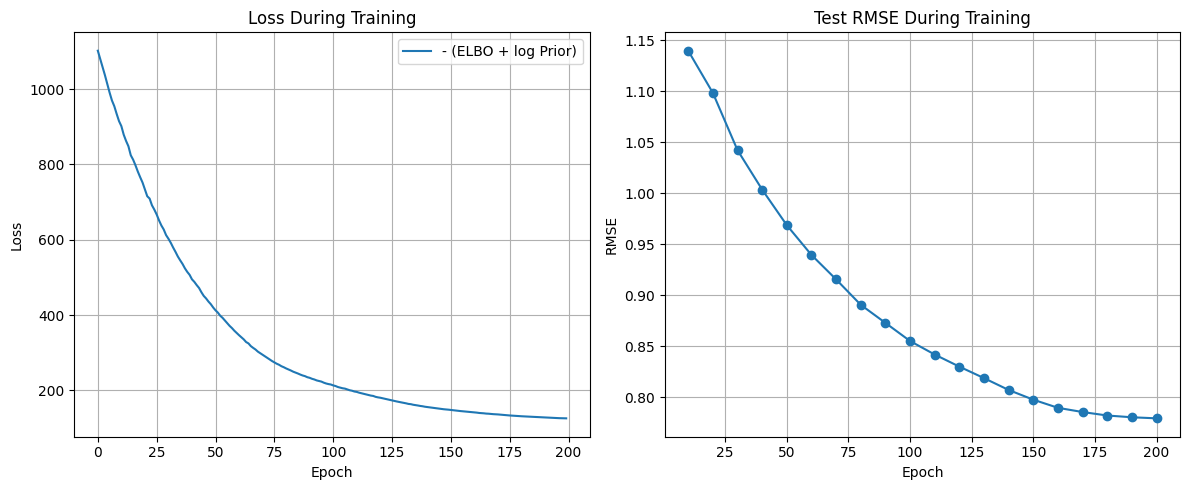

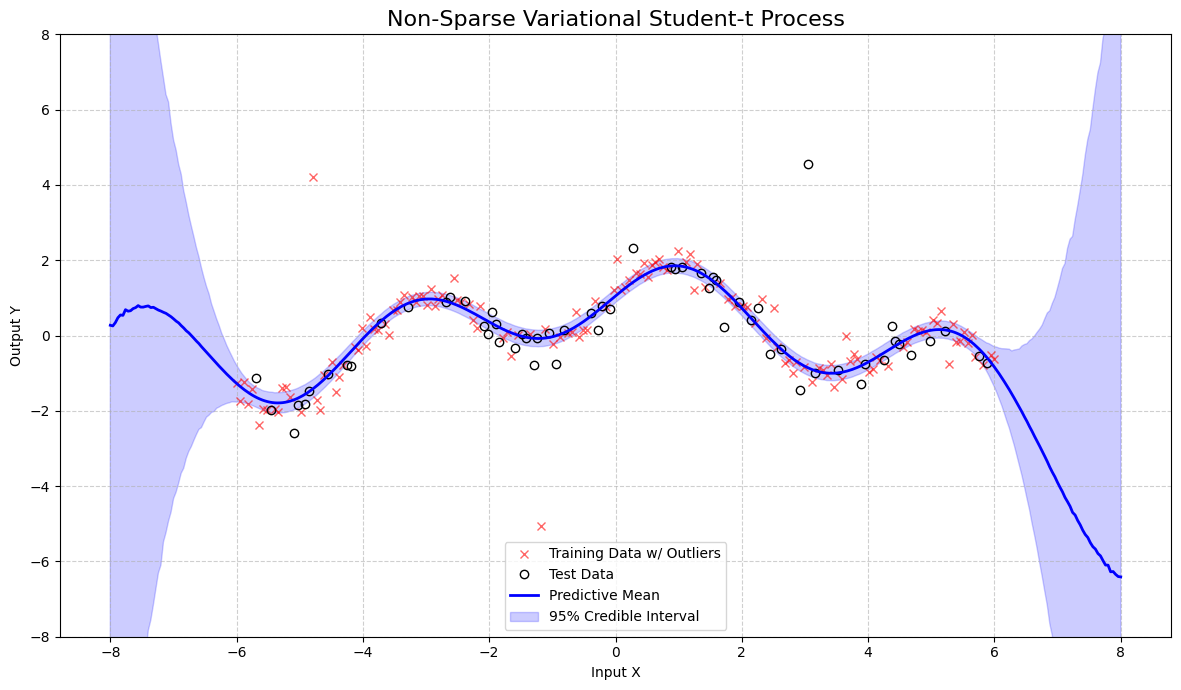

In [2]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator
import matplotlib.pyplot as plt
from scipy.stats import t as scipy_t

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class XuTPR(nn.Module):
    """
    Non-Sparse Variational Student-t Process Regression.
    Refactored to support flexible hyperparameter optimization and evaluation.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape
        dtype = self.X_train.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0) # Prior for dof_func
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)   # Prior for dof_lik
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0) # Centered around exp(-2) ~ 0.13

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Variational Parameters for q(f) ---
        self.m = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.chol_S = nn.Parameter(torch.eye(self.N, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Set kernel function
        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_train.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = final_value

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        """Returns transformed (positive) parameters from their log-space storage."""
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior
    
    def calculate_elbo(self, num_samples=1):
        params = self._get_hyperparams()

        scale_tril_q = torch.tril(self.chol_S)
        f_samples = sample_mvt(self.m, scale_tril_q, params['dof_q'], num_samples)
        lik_dist = torch.distributions.StudentT(
            df=params['dof_lik'], loc=f_samples, scale=params['noisescale'] 
        )
        expected_log_lik = lik_dist.log_prob(self.y_train).sum(0).mean()

        K_XX_base = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
        K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
        K_XX_chol = K_XX_op.cholesky()
        
        kl_div = kl_mvt_empirical(
            mu_q=self.m,
            scale_tril_q=scale_tril_q,
            dof_q=params['dof_q'],
            mu_p=torch.zeros_like(self.m),
            scale_tril_p=K_XX_chol,
            dof_p=params['dof_func'],
            num_samples=num_samples
        )
        
        return expected_log_lik - kl_div

    def fit(self, epochs=200, lr=0.01, num_mc_samples=8, X_test=None, y_test=None, eval_interval=10):
        """Trains the model by maximizing the ELBO (plus log prior for MAP)."""
        
        # Select parameters to optimize based on the specified mode
        params_to_optimize = []
        for name, p in self.named_parameters():
            # Variational parameters are always optimized
            if name in ['m', 'chol_S', 'log_dof_q']:
                params_to_optimize.append(p)
            # Hyperparameters are optimized if not 'FIX'
            elif self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                params_to_optimize.append(p)

        optimizer = optim.Adam(params_to_optimize, lr=lr) if params_to_optimize else None
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'hyperparams': [],
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting training for {epochs} epochs...")

        for epoch in range(epochs):

            fit_start_time = time.time()

            optimizer.zero_grad()
            
            elbo = self.calculate_elbo(num_samples=num_mc_samples)
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(elbo + log_prior)
            
            loss.backward()
            optimizer.step()

            fit_end_time = time.time()

            # Store history
            history['elbo'].append(elbo.item())
            history['log_prior'].append(log_prior.item())
            history['loss'].append(loss.item())
            history['hyperparams'].append({k: v.detach().cpu().numpy() for k, v in self._get_hyperparams().items()})
            history['fit_times'].append(fit_end_time - fit_start_time)


            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")

            # Evaluation Step
            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        """Generates samples from the predictive distribution q(f*)."""
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_train.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            f_samples_posterior = sample_mvt(self.m, self.chol_S, params['dof_q'], num_samples)
            
            K_XX_base = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_train, params['lengthscale'], params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            K_inv_f_samples = K_XX_op.solve(f_samples_posterior)
            predictive_loc_per_sample = K_star_X @ K_inv_f_samples
            beta_per_sample = (f_samples_posterior * K_inv_f_samples).sum(0)
            dof_pred = params['dof_func'] + self.N
            
            K_star_X_K_inv = K_XX_op.solve(K_star_X.T).T
            term2 = (K_star_X_K_inv * K_star_X).sum(1)
            
            scale_factor = (params['dof_func'] + beta_per_sample) / dof_pred
            scale_base = k_star_star_diag - term2
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_samples = pred_dist.sample()
            
        self.train()
        return predictive_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test):
        """Evaluates the model on test data and returns a dictionary of metrics."""
        predictive_samples = self.predict(X_test, num_samples=1000)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()

        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}



# --- Main execution block for testing ---
if __name__ == '__main__':
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # 1. Generate synthetic data
    torch.manual_seed(42); np.random.seed(42)
    X_data = torch.linspace(-6, 6, 200).unsqueeze(1)
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    noise = torch.from_numpy(scipy_t.rvs(df=3, size=200)).unsqueeze(1) * 0.25
    y_data = y_true + noise
    y_data[[20, 80, 150]] += torch.tensor([[6.0], [-5.0], [5.5]])

    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # 2. Initialize and train the model with hyperparameter settings
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Example: Fix the noise scale, use MAP for lengthscale, and MLE for others
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'},
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'},
        'dof_func':    {'optim': 'MAP'},
        'dof_lik':     {'optim': 'MAP'},
        # 'outputscale', 'dof_prior', 'dof_lik' will default to 'MLE'
    }

    model = XuTPR(X_train, y_train, hyper_settings=hyper_settings, device=device)
    
    history = model.fit(
        epochs=200, lr=0.01, num_mc_samples=10000,
        X_test=X_test, y_test=y_test, eval_interval=10
    )
    
    # 3. Plot optimization history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='- (ELBO + log Prior)')
    plt.title("Loss During Training")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['eval_epochs'], [m['rmse'] for m in history['eval_metrics']], 'o-')
    plt.title("Test RMSE During Training")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.grid(True); plt.tight_layout(); plt.show()
    
    # 4. Make final predictions and plot the result
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=10000)
    
    mu_pred = np.mean(predictive_samples, axis=1)
    lower, upper = np.quantile(predictive_samples, [0.025, 0.975], axis=1)

    plt.figure(figsize=(12, 7))
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data w/ Outliers', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(X_plot.squeeze().cpu(), lower, upper, color='blue', alpha=0.2, label='95% Credible Interval')
    plt.title('Non-Sparse Variational Student-t Process', fontsize=16)
    plt.xlabel('Input X'); plt.ylabel('Output Y'); plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.ylim(-8, 8); plt.show()